# 00 从零理解 LangGraph

### 目录

- 环境安装
- 一、从一个简单需求开始
- 二、LangGraph 是什么？
- 三、State 到底是什么？
- 四、Node 和 Edge：把步骤连起来
- 五、条件分支：让流程自己做决定
- 六、为什么用 LangGraph？
- 七、动手跑一下
- 八、LangSmith Studio 可视化（可选）
- 九、总结

* * *

### 环境安装

先把环境装好。建议 **Python 3.11+**。

#### 默认推荐：conda

```bash
conda create -n langgraph python=3.12
conda activate langgraph
pip install langgraph
```

验证安装：

```bash
python -c "from langgraph.version import __version__; print('langgraph', __version__)"
```

#### 备选 1：uv

```bash
mkdir langgraph-demo
cd langgraph-demo
uv init
uv add langgraph
uv run python -c "from langgraph.version import __version__; print('langgraph', __version__)"
```

#### 备选 2：pip + venv

```bash
python -m venv .venv
# Windows: .venv\Scripts\activate
# Mac/Linux: source .venv/bin/activate
pip install langgraph
python -c "from langgraph.version import __version__; print('langgraph', __version__)"
```

* * *

### 一、从一个简单需求开始

假设你想做一个“请假审批小助手”。

最粗暴的做法：把一句话丢给模型，让它直接给结论。

In [1]:
# 最简单的“模型调用”（这里只用一个 mock，保证离线可跑）
def llm(prompt: str) -> str:
    return f"（示例输出）已收到请求：{prompt}"


result = llm("帮我处理请假申请：小明请假 2 天，原因感冒")
print(result)

（示例输出）已收到请求：帮我处理请假申请：小明请假 2 天，原因感冒


这能跑，但真实的“审批小助手”通常不止一步：

- 先做规则检查（比如天数是否超限）
- 再查余额/历史记录（可能并行）
- 必要时转主管确认（人工参与）
- 最后落库/归档/通知

这就是一个**多步骤、有分支、可能需要人工介入**的流程。

如果你把所有逻辑硬塞进一个函数里，很快就会变得难维护。LangGraph 的价值就在于：**把流程拆成节点，用图来组织它们的执行顺序**。

* * *

### 二、LangGraph 是什么？

一句话：**LangGraph 让你用“流程图”的方式组织一个有状态的工作流。**

> **类比：审批流水线**
>
> - **工位**（Node）：每个工位做一件事（校验、查询、审批、归档）
> - **传送带**（Edge）：连接工位，决定下一步去哪
> - **审批单**（State）：单子跟着流程走，记录当前信息与进度
> - **布局图**（Graph）：把工位与传送带装配起来

四个核心概念：

| 概念 | 说明 | 类比 |
| --- | --- | --- |
| State（状态） | 在流程中传递的共享数据快照，节点可读可写 | 一张审批单 |
| Node（节点） | 一个步骤函数：读 state，返回增量 update | 一个工位 |
| Edge（边） | 节点之间的连接：固定或按条件分流 | 传送带/分流口 |
| Graph（图） | 把节点和边组装成可执行的流程 | 流水线布局图 |

* * *

### 三、State 到底是什么？

State 是 LangGraph 最重要的东西：**它就是一个 dict**，在所有节点之间传递。

> **类比：审批单**
>
> - 单子上写着：申请人、天数、原因、当前状态
> - “提交”工位把状态改成“已提交”
> - “审批”工位把状态改成“已批准/已拒绝”并写上意见
>
> 这张单子，就是大家共享并不断被更新的 State。

在代码里，我们经常用 `TypedDict` 来描述它的结构：


In [2]:
from typing_extensions import TypedDict


class ApprovalState(TypedDict):
    employee: str  # 申请人
    days: int  # 请假天数
    reason: str  # 原因
    status: str  # 当前状态

每个节点都能拿到这份 State：读里面的信息，然后只返回它要改的那一小部分（增量 update）：

In [3]:
def submit_request(state: ApprovalState):
    # 读取：看审批单内容
    print(f"申请人 {state['employee']} 请假 {state['days']} 天，原因：{state['reason']}")

    # 修改：只返回要改的字段
    return {"status": "已提交"}
    # 其他字段保持不变

**检查理解：**

初始状态：`{"employee": "小明", "days": 2, "reason": "感冒", "status": "新建"}`

经过「提交」节点后，状态会变成什么？

- A. `{"employee": "小明", "days": 2, "reason": "感冒", "status": "已提交"}`
- B. `{"status": "已提交"}`
- C. `{"employee": "小明", "days": 2, "reason": "感冒", "status": "新建", "note": "已提交"}`

> 答案是 **A**。节点只返回 `{"status": "已提交"}`，其他字段保持不变，LangGraph 会把 update 合并回原 state。

* * *

### 四、Node 和 Edge：把步骤连起来

- **Node（节点）**：一个 Python 函数，输入 state，输出增量 update
- **Edge（边）**：规定“这个节点跑完以后下一步去哪”

**最简单的流程：一条直线**

```text
START → 提交 → 审批 → 归档 → END
```

代码怎么写：

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class ApprovalState(TypedDict):
    employee: str
    days: int
    reason: str
    status: str


def submit(state: ApprovalState):
    return {"status": "已提交"}


def review(state: ApprovalState):
    # 这里只做最简单的规则示例
    if state["days"] <= 1:
        return {"status": "已批准"}
    return {"status": "待主管审批"}


def archive(state: ApprovalState):
    return {"status": "已归档"}


# 1. 创建一个「流水线建造者」
builder = StateGraph(ApprovalState)

# 2. 添加工位（节点）
builder.add_node("提交", submit)
builder.add_node("审批", review)
builder.add_node("归档", archive)

# 3. 连接传送带（边）
builder.add_edge(START, "提交")
builder.add_edge("提交", "审批")
builder.add_edge("审批", "归档")
builder.add_edge("归档", END)

# 4. 编译（把布局图变成可执行的流水线）
graph = builder.compile()

# 5. 运行！
result = graph.invoke({
    "employee": "小明",
    "days": 2,
    "reason": "感冒",
    "status": "新建",
})
result

{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已归档'}

* * *

### 五、条件分支：让流程自己做决定

现实里的审批流程也不是一条直线。比如：

```text
               ┌─ 天数 ≤ 1 → 自动通过
提交 → 分流判断 ┤
               └─ 天数 > 1 → 转主管审批
```

这就是**条件边（Conditional Edge）**：根据当前状态，决定走哪条路。


In [5]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class BranchState(TypedDict):
    days: int
    status: str


def decide_route(state: BranchState):
    # 节点只做状态更新（这里可理解为“把申请标记为已进入判断环节”）
    return {"status": "已进入分流"}


def auto_approve(state: BranchState):
    return {"status": "已批准（自动）"}


def manager_review(state: BranchState):
    return {"status": "已批准（主管）"}


def route(state: BranchState) -> Literal["auto_approve", "manager_review"]:
    return "auto_approve" if state["days"] <= 1 else "manager_review"


builder = StateGraph(BranchState)
builder.add_node("分流判断", decide_route)
builder.add_node("auto_approve", auto_approve)
builder.add_node("manager_review", manager_review)

builder.add_edge(START, "分流判断")
builder.add_edge("auto_approve", END)
builder.add_edge("manager_review", END)

# 添加条件边：根据 route 的返回值选择下一步
builder.add_conditional_edges(
    "分流判断",  # 从哪个节点出发
    route,        # 路由函数——决定下一步去哪
)

graph = builder.compile()

graph.invoke({"days": 1, "status": "新建"}), graph.invoke({"days": 3, "status": "新建"})

({'days': 1, 'status': '已批准（自动）'}, {'days': 3, 'status': '已批准（主管）'})

* * *

### 六、为什么用 LangGraph？

你可能会想：「我用 if-else 也能写啊，为什么要用 LangGraph？」

| 需求 | 纯 if-else | LangGraph |
| --- | --- | --- |
| 简单流程 | 能写 | 能写 |
| 多步骤 + 分支 | 代码越来越乱 | 图结构清晰 |
| 需要人工确认 | 很难实现 | 内置支持（后续章节会讲） |
| 记住对话历史 | 自己管理状态 | 有成熟模式（后续章节会讲） |
| 并行执行 | 要写并发控制 | 声明式表达 |
| 调试和可视化 | 靠 print | 有配套工具（可选） |

**简单说：** 当你的 AI 流程超过 3 步、有分支、需要记忆/可恢复，用 LangGraph 更稳。

* * *

### 七、动手跑一下

下面用“审批单”例子完整跑一遍。


In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# ---- 第1步：定义 State（审批单）----
class ApprovalState(TypedDict):
    employee: str
    days: int
    reason: str
    status: str


# ---- 第2步：定义节点函数 ----
def submit(state: ApprovalState):
    print(f"[提交] {state['employee']} 请假 {state['days']} 天，原因：{state['reason']}")
    return {"status": "已提交"}


def review(state: ApprovalState):
    if state["days"] <= 1:
        print("[审批] 符合自动通过规则")
        return {"status": "已批准"}
    print("[审批] 需要主管确认")
    return {"status": "待主管审批"}


def archive(state: ApprovalState):
    print("[归档] 归档完成")
    return {"status": "已归档"}


# ---- 第3步：组装图 ----
builder = StateGraph(ApprovalState)

builder.add_node("提交", submit)
builder.add_node("审批", review)
builder.add_node("归档", archive)

builder.add_edge(START, "提交")
builder.add_edge("提交", "审批")
builder.add_edge("审批", "归档")
builder.add_edge("归档", END)

graph = builder.compile()


# ---- 第4步：查看图结构 ----
graph_data = graph.get_graph()
print("节点:", [n.id for n in graph_data.nodes.values()])
print("边:", [(e.source, e.target) for e in graph_data.edges])


# ---- 第5步：运行一次 ----
result = graph.invoke({
    "employee": "小明",
    "days": 2,
    "reason": "感冒",
    "status": "新建",
})

print(f"\n最终结果: {result}")

节点: ['__start__', '提交', '审批', '归档', '__end__']
边: [('__start__', '提交'), ('审批', '归档'), ('提交', '审批'), ('归档', '__end__')]
[提交] 小明 请假 2 天，原因：感冒
[审批] 需要主管确认
[归档] 归档完成

最终结果: {'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已归档'}


下面再加两种“更直观”的观察方式：

- 直接画出流程图（PNG）
- 用 `updates` / `values` 看到每一步 state 怎么变

#### 1）画出流程图（PNG）

运行下一格代码，会在 notebook 里显示流程图。

#### 2）用 updates / values 看 state 的变化

运行再下一格代码，你会看到：

- `updates`：每个节点返回的增量 update
- `values`：每一步合并后的完整 state 快照


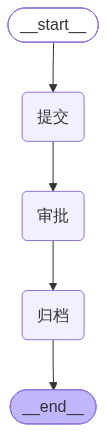

In [7]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [8]:
init_state: ApprovalState = {
    "employee": "小明",
    "days": 2,
    "reason": "感冒",
    "status": "新建",
}

print("=== init_state ===")
print(init_state)
print()

print("=== updates（每个节点返回的增量 update）===")
for chunk in graph.stream(init_state, stream_mode="updates"):
    print(chunk)
print()

print("=== values（合并后的 state 快照）===")
for i, snapshot in enumerate(graph.stream(init_state, stream_mode="values")):
    print(f"-- step {i} --")
    print(snapshot)
    print()

=== init_state ===
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '新建'}

=== updates（每个节点返回的增量 update）===
[提交] 小明 请假 2 天，原因：感冒
{'提交': {'status': '已提交'}}
[审批] 需要主管确认
{'审批': {'status': '待主管审批'}}
[归档] 归档完成
{'归档': {'status': '已归档'}}

=== values（合并后的 state 快照）===
-- step 0 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '新建'}

[提交] 小明 请假 2 天，原因：感冒
-- step 1 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已提交'}

[审批] 需要主管确认
-- step 2 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '待主管审批'}

[归档] 归档完成
-- step 3 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已归档'}



* * *


运行后你应该看到：

```text
[提交] 小明 请假 2 天，原因：感冒
[审批] 需要主管确认
[归档] 归档完成

最终结果: {'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已归档'}
```

注意看：`status` 会随着节点推进逐步更新。

* * *

### 八、LangSmith Studio 可视化（可选）

Studio 的价值很简单：**把“图怎么跑、每一步 state 怎么变”可视化出来**，比你手写一堆 `print()` 更直观。

#### 架构说明（谁在本地，谁在云端）

```text
你的电脑（本地）                         云端（前端 UI）
┌─────────────────────┐                 ┌────────────────────────┐
│ langgraph dev        │  HTTP 连接      │ LangSmith Studio UI      │
│ 本地开发服务器        │  <───────────>  │ 只是界面，不执行代码      │
│ http://127.0.0.1:2024│                 │ https://smith.langchain… │
└─────────────────────┘                 └────────────────────────┘
        │
   执行代码 / 存储 state
        │
        ▼
    你的数据仍在本地
```

- **代码执行**：在你电脑上跑
- **Studio UI**：只是一个前端界面，用 `baseUrl` 连你的本地服务
- **是否需要 API Key**：
  - 不配置也能用 UI 调试（但不会把 trace 保存到云端）
  - 配置后可以把 trace 保存/回看（方便协作与回放）

#### 1）安装 CLI

```bash
uv add "langgraph-cli[inmem]"
```

> 如果你的 Python 版本低于 3.11，建议先升级到 3.11+。

#### 2）创建 `langgraph.json`

在项目根目录创建 `langgraph.json`：

```json
{
  "dependencies": ["."],
  "graphs": {
    "demo": "./demo.py:graph"
  },
  "env": "./.env"
}
```

- `"./demo.py:graph"`：表示从 `demo.py` 里找名为 `graph` 的变量
- `"env": "./.env"`：表示从 `.env` 加载环境变量

#### 3）创建 `.env`（二选一）

**方法一：纯本地调试（不保存 trace）**

```text
LANGSMITH_TRACING=false
```

**方法二：保存 trace（可选）**

```text
LANGSMITH_TRACING=true
LANGSMITH_API_KEY=你的key
```

#### 4）启动 Studio

```bash
uv run langgraph dev
```

你会看到类似输出：

```text
API: http://127.0.0.1:2024
Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
```

用浏览器打开 `Studio UI` 那一行即可。

#### 5）怎么在 UI 里测试

- **左侧 Graph**：能看到节点与边（图结构）
- **右侧 Input**：填入 state 初始字段（对应你的 `TypedDict`）
- 点击 **Submit**：运行图
- 打开 **Trace**：逐步查看每个节点的执行顺序与 state 变化

你会看到 `status` 怎么被每个节点更新，这比你在终端翻日志更直观。

* * *

### 九、总结

| 概念 | 一句话解释 | 类比 |
| --- | --- | --- |
| State | 所有节点共享的数据（dict） | 一张审批单 |
| Node | 做一件事的函数 | 流水线工位 |
| Edge | 节点之间的连接 | 传送带 |
| Graph | 把节点和边组装起来 | 流程布局图 |
| 条件边 | 根据 state 决定去哪个节点 | 分流路口 |
| compile() | 把图编译成可运行对象 | 把图纸变成流水线 |

**核心记忆：**

**LangGraph = 用流程图的方式组织一个有状态的工作流。**

你只要定义「有哪些步骤」和「步骤之间怎么连」，执行与合并交给框架处理。

#### 参考

- [LangGraph 总览文档](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Studio 快速开始](https://docs.langchain.com/langsmith/quick-start-studio)
